In [1]:
import sys
sys.path.append("..")
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import math
fastf1.Cache.enable_cache('../f1cache')  # replace with your cache directory
# Get rid of an error
pd.options.mode.chained_assignment = None

In [3]:
Year = 2024
Track_Name = 11
Session_Name = 'Q' #Quafi = Q FP1 FP2 FP3 RACE Sprint
Driver = "LEC"
Lap = 7

Session = fastf1.get_session(Year, Track_Name, Session_Name)
Session.load()

core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.3.8]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO

In [4]:
laps = Session.laps
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps_wo = Session.laps.pick_wo_box().pick_driver(Driver).pick_wo_box()

# # TODO do lap selector to mach choosen lap or if to validate the choise
telemetry = laps_wo.get_telemetry().add_differential_distance()
# laps_wo.to_csv(f"output/{Track_Name}_{Session_Name}_{Driver}_Lwo.csv", index=False)
# telemetry.to_csv(f"output/{Track_Name}_{Session_Name}_{Driver}_Lwo_telemetry.csv", index=False)
# laps = laps.loc[(laps['PitOutTime'].isnull() & laps['PitInTime'].isnull())]
# telemetry = laps.get_telemetry().add_differential_distance()


In [5]:
# df0 = pd.DataFrame(telemetry[["Speed","RPM","Time", 'nGear', 'Throttle', 'Brake', 'DRS',"Distance","Source","DifferentialDistance",
                                #    'RelativeDistance']])
df1 =pd.DataFrame(telemetry[["Speed","RPM",'nGear',"DifferentialDistance","Time","DRS","Brake","Throttle"]])
df1.to_csv(f"output/{Track_Name}_{Session_Name}_{Driver}_Lwo_gearratio.csv", index=False)

In [6]:
def get_gear_ratio(tire_radius, Gear, data, drs=False):
    xy = []
    for row in data:
        speed_kmh, engine_rpm, nGear,distance,time,nDrs,brake,throttle = row
        drs_n = 8 if drs == False else 12
        if speed_kmh > 0 and nGear==Gear and brake == False and nDrs==drs_n and throttle==100: #and rpm >10700:
        #     speed_ms = speed_kmh * 5 / 18  # km/h to m/s
        #     speed_mm = speed_ms * 60 #m/min
        #     speed_mm = speed_kmh * 60 * 0.001 #m/min
            # tire_rpm = (speed_kmh * (1000/60) * 30) / (tire_radius * math.pi  )
            tire_rpm = (speed_kmh * (5)) / (tire_radius * math.pi  )
            # gear_ratio = final dirve ratio * gearbox gear ratio
            gear_ratio = (3.6 * engine_rpm * math.pi * tire_radius)  / (30 * speed_kmh)
            print(f"{engine_rpm} / {tire_rpm} = {engine_rpm / tire_rpm}  => {gear_ratio}")
            if gear_ratio!= math.inf :#and gear_ratio <=14:
                xy.append([speed_kmh, nGear,engine_rpm,gear_ratio,nDrs,throttle])
            else:
                print(f"Error Gear ratio = {gear_ratio}")
            return xy

1 3810 9778 2720
1 (6600.0, 7145.455]
2 6868 11580 4257
2 (6600.0, 7145.455]
3 10187 12034 5841
3 (10418.182, 10963.636]
4 8762 12339 7516
4 (10963.636, 11509.091]
5 10899 12325 7720
5 (10963.636, 11509.091]
6 10722 12460 7276
6 (10963.636, 11509.091]
7 11130 11850 8950
7 (10963.636, 11509.091]
8 11348 11547 9578
8 (10418.182, 10963.636]


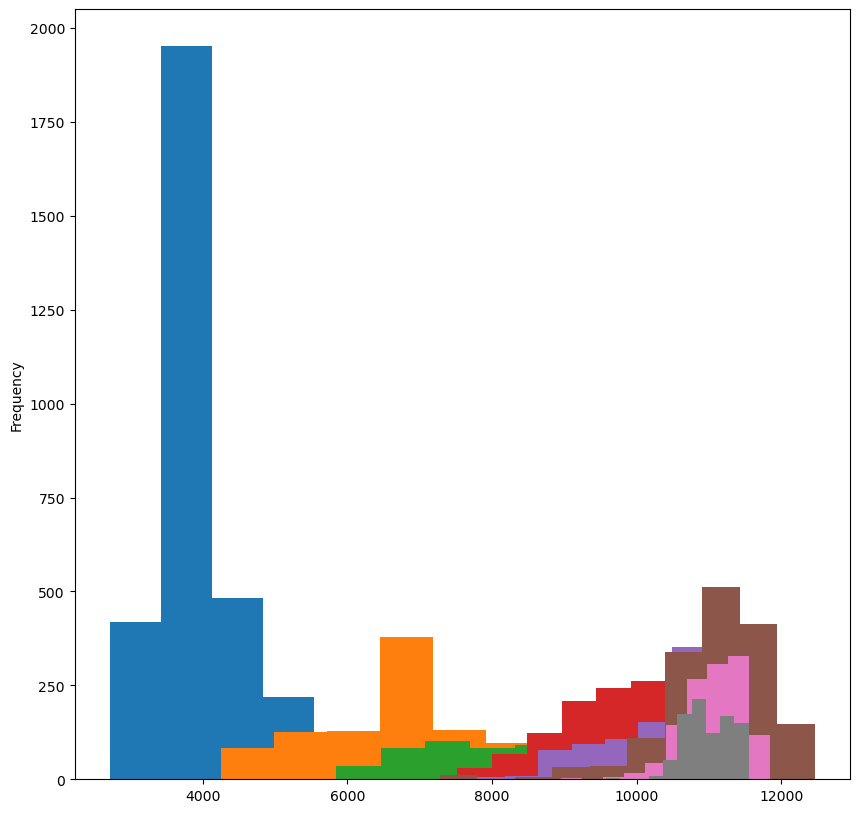

In [70]:
# df1 = df1[df1.nGear==8]
df1 = df1[df1.nGear>0]
df1 = df1[df1.Brake==False]
# df1 = df1[df1.DRS==8]
cut_bins = np.linspace(6600,12600,12)
results = []
for gear in range(1, 9):  # Supposons un maximum de 8 vitesses
    gears = df1[(df1['nGear'] == gear)]
    if not gears.empty:
        # Calculer le quartile inférieur pour RPM et Speed
        rpm_q1 = gears['RPM'].quantile(0.25)
        q75, q25 = df1['RPM'].quantile(0.75), df1['RPM'].quantile(0.25)
        intr_qr = q75 - q25
        # rpm_max = q75 + (1.5 * intr_qr) # IQR proximity rule: Max = q75 + 1,5 * IQR
        rpm_min = q25 - (1.5 * intr_qr) # IQR proximity rule: Min = q25 + 1,5 * IQR
        # print(gears[(gears['RPM'] > rpm_min)]['RPM'].describe())
        # print(gears['RPM'].describe())
        print(gear, gears['RPM'].value_counts().idxmax(),gears['RPM'].max(),gears['RPM'].min())
        gears['RPM'].plot(kind='hist')
        gears_bins = pd.cut(gears['RPM'],bins=cut_bins)
        print(gear, gears_bins.value_counts().idxmax())
        results.append(gears[(gears['RPM'] > rpm_min)]['RPM'])
# gears = pd.DataFrame(results)
gears = results
results=None
# gears = [gears[_][gears[_].RPM] for _ in range(0,8)]
# df1.loc[df1['RPM'] < 9500, 'RPM'] = np.nan
# df1.loc[df1['RPM'] > rpm_max, 'RPM'] = np.nan
# df1 = df1.filter(items=['RPM','nGear'])
# gears = [df1['RPM'][df1.nGear==_] for _ in range(1,9)]
# df1 = df1[df1['RPM'].dropna()]




[Text(0, 0.5, 'PRM')]

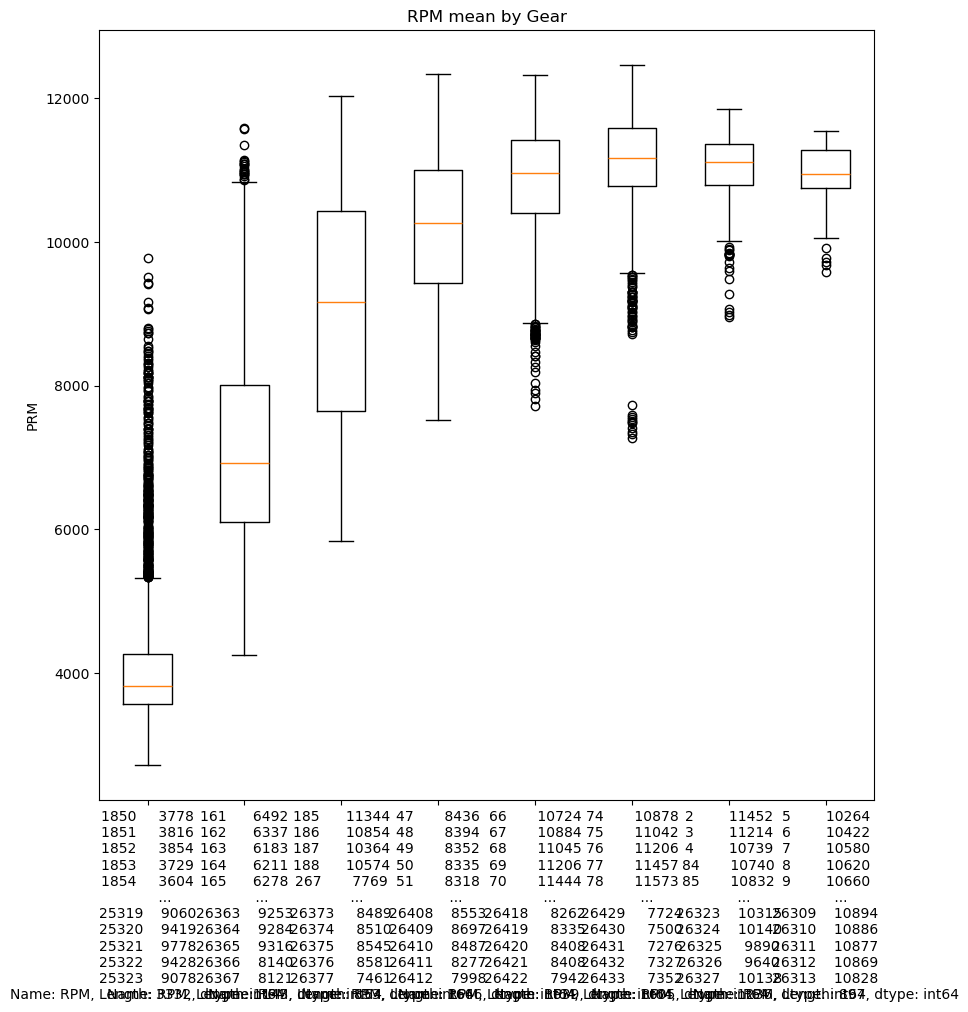

In [71]:
# Make plot a bit bigger
plt.rcParams['figure.figsize'] = [10, 10]

# Create 2 subplots (1 for the boxplot, 1 for the lap-by-lap comparison)
fig, ax = plt.subplots()


##############################
#
# Boxplot for average racepace
#
##############################


ax.boxplot(gears, labels=gears)

ax.set_title('RPM mean by Gear')
ax.set(ylabel = 'PRM')

In [ ]:


data = df1.to_numpy()
gear_ratios = []

tire_diameter = 0.705 # in meters
tire_radius = tire_diameter * 0.5
convertion_factor = 1000 / np.pi * 60  # m in a kilometer / PI * min in an hour
Xy = get_gear_ratio(tire_radius, 8 ,data)


# poly = PolynomialFeatures(degree=2)
# X_poly = poly.fit_transform(X)

# print(regressor.predict(np.array([[]]))


In [ ]:
plt.hist(Xy, bins=20, density=False, alpha=0.6, color='b')

In [ ]:
x=np.array(x).reshape(-1,1)
y=np.array(y).reshape(-1,1)
print(y.mean())

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import (LinearRegression, RANSACRegressor)
from matplotlib import cm
N_OUTLIERS = 15
lr = LinearRegression().fit(x,y)
coef_list = [["linear_regression", lr.coef_[0]]]
plotline_X = np.arange(x.min(), x.max()).reshape(-1, 1)
plotline_X_f = plotline_X.flatten()
fit_df = pd.DataFrame(
	index = plotline_X_f,
	columns = ["linear_regression"],
	data= lr.predict(plotline_X)
)
print(f"Linear mean ({fit_df['linear_regression'].mean()})")
fig, ax = plt.subplots(2, 1, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
fit_df.plot(ax=ax[0])
ax[0].scatter(x, y, c="k")
# ax[0,0].title("Linear regression on data with outliers")

ransac = RANSACRegressor(random_state=42).fit(x, y)
fit_df["ransac_regression"] = ransac.predict(plotline_X)
ransac_coef = ransac.estimator_.coef_
coef_list.append(["ransac_regression", ransac.estimator_.coef_[0]])
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask
print(f"X,y (min, max) x({x.min()} {x.max()}) y({y.min()} {y.max()})")
print(f"Ransac Score: {ransac.score(x,y)}")
print(f"Total outliers: {sum(outlier_mask)}")
print(f"Outliers you added yourself: {sum(outlier_mask[:N_OUTLIERS])} / {N_OUTLIERS}")
print(f"Linear mean ({fit_df['linear_regression'].mean()})")
print(f"Inlaier Mean : {y[inlier_mask].mean()}")
print(f"Intercept (liner vs Ransac) : {lr.intercept_} / {ransac.estimator_.intercept_}")
print(f"Slope (liner vs Ransac) : {lr.coef_} / {ransac.estimator_.coef_}")
# fix, ax = plt.subplots()
fit_df.plot(ax=ax[1])
ax[1].scatter(x[inlier_mask], y[inlier_mask], color="blue", label="Inliers")
ax[1].scatter(x[outlier_mask], y[outlier_mask], color="red", label="Outliers")
# ax[1,0].title("RANSAC - outliers vs inliers")
plt.show()
# Xy = np.array(Xy)


In [ ]:
xy = np.array(Xy)
x = xy[:,0]
y = xy[:,2]
x = x.reshape(-1,1)
y = y.reshape(-1,1)
N_OUTLIERS = 15
lr = LinearRegression().fit(x,y)
coef_list = [["linear_regression", lr.coef_[0]]]
plotline_X = np.arange(x.min(), x.max()).reshape(-1, 1)
plotline_X_f = plotline_X.flatten()
fit_df = pd.DataFrame(
	index = plotline_X_f,
	columns = ["linear_regression"],
	data= lr.predict(plotline_X)
)
print(f"Linear mean ({fit_df['linear_regression'].mean()})")
fig, ax = plt.subplots(2, 1, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
fit_df.plot(ax=ax[0])
ax[0].scatter(x, y, c="k")
# ax[0,0].title("Linear regression on data with outliers")

ransac = RANSACRegressor(random_state=42).fit(x, y)
fit_df["ransac_regression"] = ransac.predict(plotline_X)
ransac_coef = ransac.estimator_.coef_
coef_list.append(["ransac_regression", ransac.estimator_.coef_[0]])
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask
print(f"X,y (min, max) x({x.min()} {x.max()}) y({y.min()} {y.max()})")
print(f"Ransac Score: {ransac.score(x,y)}")
print(f"Total outliers: {sum(outlier_mask)}")
print(f"Outliers you added yourself: {sum(outlier_mask[:N_OUTLIERS])} / {N_OUTLIERS}")
print(f"Linear mean ({fit_df['linear_regression'].mean()})")
print(f"Inlaier Mean : {y[inlier_mask].mean()}")
print(f"Intercept (liner vs Ransac) : {lr.intercept_} / {ransac.estimator_.intercept_}")
print(f"Slope (liner vs Ransac) : {lr.coef_} / {ransac.estimator_.coef_}")
# fix, ax = plt.subplots()
fit_df.plot(ax=ax[1])
ax[1].scatter(x[inlier_mask], y[inlier_mask], color="blue", label="Inliers")
ax[1].scatter(x[outlier_mask], y[outlier_mask], color="red", label="Outliers")
# ax[1,0].title("RANSAC - outliers vs inliers")
plt.show()
# Xy = np.array(Xy)

In [ ]:
import numpy as np
def calculate_wheel_rpm(speed_kmh, tire_diameter_m):
    wheel_circumference = math.pi * tire_diameter_m
    speed_mps = speed_kmh / 3.6
    wheel_rps = speed_mps / wheel_circumference
    wheel_rpm = wheel_rps * 60
    return wheel_rpm

def estimate_and_refine_gear_ratios(group):
    gear_ratios = {}
    refined_ratios = {}
    stats = {}
    for gear in range(1, 9):  # Supposons un maximum de 8 vitesses
        gear_data = group[group['nGear'] == gear]
        if not gear_data.empty:
            ratios = gear_data['RPM'] / gear_data['wheel_rpm']

            # Filtrage des valeurs aberrantes
            q1, q3 = np.percentile(ratios, [25, 75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            filtered_ratios = ratios[(ratios >= lower_bound) & (ratios <= upper_bound)]

            refined_ratios[gear] = np.median(filtered_ratios)
            stats[gear] = {
                'mean': np.mean(filtered_ratios),
                'std': np.std(filtered_ratios),
                'min': np.min(filtered_ratios),
                'max': np.max(filtered_ratios),
                'count': len(filtered_ratios)
            }

    return refined_ratios, stats

def refine_gear_ratios(gear_ratios):
    refined_ratios = {}
    for gear, ratios in gear_ratios.items():
        q1, q3 = np.percentile(ratios, [25, 100])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        filtered_ratios = ratios[(ratios >= lower_bound) & (ratios <= upper_bound)]
        refined_ratios[gear] = np.median(filtered_ratios)
    return refined_ratios

In [ ]:
quali = fastf1.get_session(2023, 1, 'Q')

quali.load()
quali.drivers

In [ ]:

def get_quali_telemetry(event,year=2023):
    try:
        quali = fastf1.get_session(year, event['EventName'], 'Q')

        quali.load()
        all_driver_telemetry = []
        for driver in quali.drivers:
            # get laps without pit in or out
            driver_laps = quali.laps.pick_wo_box().pick_driver(driver)
            # Get telemetry data for all laps of this driver
            telemetry = driver_laps.get_telemetry()

            # Add event and driver information to the telemetry data
            telemetry['EventName'] = event['EventName']
            telemetry['RoundNumber'] = event['RoundNumber']
            telemetry['Driver'] = driver
            all_driver_telemetry.append(telemetry)

        # Combine all drivers' telemetry for this event
        event_telemetry = pd.concat(all_driver_telemetry, ignore_index=True)

        return event_telemetry
    except Exception as e:
        print(f"Error processing {event['EventName']}: {str(e)}")
        return None




In [ ]:
year = 2023  # Replace with the year you're interested in
schedule = fastf1.get_event_schedule(year)
all_telemetry = []
for _, event in schedule.iterrows():
    print(f"Processing {event['EventName']}...")
    telemetry = get_quali_telemetry(event)
    if telemetry is not None:
        all_telemetry.append(telemetry)

# Combine all telemetry data into a single DataFrame
combined_telemetry = pd.concat(all_telemetry, ignore_index=True)

# Save the combined telemetry data to a CSV file
combined_telemetry.to_csv(f'quali_telemetry_{year}.csv', index=False)
print(f"Telemetry data saved to quali_telemetry_{year}.csv")

In [ ]:
import pandas as pd

# Charger les données télémétriques
data = pd.read_csv('quali_telemetry_2023.csv')

# Calculer le RPM des roues
tire_diameter = 0.720  # en mètres
data['wheel_rpm'] = data.apply(lambda row: calculate_wheel_rpm(row['Speed'], tire_diameter), axis=1)


# Grouper les données par session et pilote
# grouped_data = data.groupby(['RoundNumber', 'Driver'])
grouped_data = data.groupby(['Driver'])



In [ ]:
data=None

results = []
# for (session, driver), group in grouped_data:
for (driver), group in grouped_data:
    # Estimer et affiner les ratios de rapports pour ce groupe
    refined_ratios, stats = estimate_and_refine_gear_ratios(group)
    results.append({
        # 'Session': session,
        'Session': 2023,
        'Driver': driver,
        'RefinedRatios': refined_ratios,
        'Stats': stats
    })

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Afficher les résultats
for _, row in results_df.iterrows():
    print(f"\nSession: {row['Session']}, Pilote: {row['Driver']}")
    print("Ratios de rapports estimés :")
    for gear, ratio in row['RefinedRatios'].items():
        print(f"Rapport {gear}: {ratio:.3f}")
        stats = row['Stats'][gear]
        print(f"  Moyenne: {stats['mean']:.3f}, Écart-type: {stats['std']:.3f}")
        print(f"  Min: {stats['min']:.3f}, Max: {stats['max']:.3f}, Nombre d'échantillons: {stats['count']}")

# Optionnel : sauvegarder les résultats dans un fichier CSV
results_df.to_csv('estimated_gear_ratios_with_stats.csv', index=False)

data = group = None



# # Estimer les ratios de rapports
# estimated_ratios = estimate_gear_ratios(data)

# # Affiner les estimations
# refined_ratios = refine_gear_ratios(estimated_ratios)

# print("Ratios de rapports estimés :")
# for gear, ratio in refined_ratios.items():
#     print(f"Rapport {gear}: {ratio:.3f}")

In [ ]:
def combine_ratios(ratios_list):
    combined = {}
    for ratios in ratios_list:
        for gear, ratio in ratios.items():
            if gear not in combined:
                combined[gear] = []
            combined[gear].append(ratio)
    return combined

def calculate_overall_stats(combined_ratios):
    stats = {}
    for gear, ratios in combined_ratios.items():
        stats[gear] = {
            'median': np.median(ratios),
            'mean': np.mean(ratios),
            'std': np.std(ratios),
            'min': np.min(ratios),
            'max': np.max(ratios),
            'count': len(ratios)
        }
    return stats

# Grouper les résultats par pilote
grouped_results = results_df.groupby('Driver')

overall_results = []

for driver, group in grouped_results:
    # Combiner tous les ratios estimés pour ce pilote
    combined_ratios = combine_ratios(group['RefinedRatios'].tolist())
    
    # Calculer les statistiques globales pour ce pilote
    overall_stats = calculate_overall_stats(combined_ratios)
    
    overall_results.append({
        'Driver': driver,
        'OverallStats': overall_stats
    })

# Convertir les résultats en DataFrame
overall_results_df = pd.DataFrame(overall_results)

# Afficher les résultats
for _, row in overall_results_df.iterrows():
    print(f"\nPilote: {row['Driver']}")
    print("Ratios de rapports estimés (global) :")
    for gear, stats in row['OverallStats'].items():
        print(f"Rapport {gear}:")
        print(f"  Médiane: {stats['median']:.3f}, Moyenne: {stats['mean']:.3f}, Écart-type: {stats['std']:.3f}")
        print(f"  Min: {stats['min']:.3f}, Max: {stats['max']:.3f}, Nombre d'échantillons: {stats['count']}")

# Optionnel : sauvegarder les résultats dans un fichier CSV
overall_results_df.to_csv('overall_gear_ratios_by_driver.csv', index=False)

In [ ]:
def analyze_gear_shifts(group):
    gear_shift_data = {}
    for gear in range(1, 9):  # Supposons un maximum de 8 vitesses
        gear_data = group[group['nGear'] == gear]
        if not gear_data.empty:
            # Calculer le quartile inférieur pour RPM et Speed
            rpm_q1 = gear_data['RPM'].quantile(0.25)
            speed_q1 = gear_data['Speed'].quantile(0.25)

            # Filtrer les données pour exclure le quartile inférieur
            filtered_data = gear_data[(gear_data['RPM'] > rpm_q1) & (gear_data['Speed'] > speed_q1)]

            if not filtered_data.empty:
                gear_shift_data[gear] = {
                    'rpm_stats': {
                        'mean': filtered_data['RPM'].mean(),
                        'median': filtered_data['RPM'].median(),
                        'std': filtered_data['RPM'].std(),
                        'min': filtered_data['RPM'].min(),
                        'max': filtered_data['RPM'].max()
                    },
                    'speed_stats': {
                        'mean': filtered_data['Speed'].mean(),
                        'median': filtered_data['Speed'].median(),
                        'std': filtered_data['Speed'].std(),
                        'min': filtered_data['Speed'].min(),
                        'max': filtered_data['Speed'].max()
                    },
                    'correlation': np.corrcoef(filtered_data['RPM'], filtered_data['Speed'])[0, 1],
                    'sample_size': len(filtered_data)
                }
    return gear_shift_data

# Charger les données télémétriques
data = pd.read_csv('quali_telemetry_2023.csv')

# Grouper les données par pilote
grouped_data = data.groupby('Driver')

results = []

for driver, group in grouped_data:
    gear_shift_analysis = analyze_gear_shifts(group)
    
    results.append({
        'Driver': driver,
        'GearShiftAnalysis': gear_shift_analysis
    })

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Afficher les résultats
for _, row in results_df.iterrows():
    print(f"\nPilote: {row['Driver']}")
    for gear, analysis in row['GearShiftAnalysis'].items():
        print(f"\nRapport {gear}:")
        print("  RPM au changement de vitesse:")
        print(f"    Moyenne: {analysis['rpm_stats']['mean']:.0f}")
        print(f"    Médiane: {analysis['rpm_stats']['median']:.0f}")
        print(f"    Écart-type: {analysis['rpm_stats']['std']:.0f}")
        print(f"    Min: {analysis['rpm_stats']['min']:.0f}")
        print(f"    Max: {analysis['rpm_stats']['max']:.0f}")
        print("  Vitesse au changement de vitesse (km/h):")
        print(f"    Moyenne: {analysis['speed_stats']['mean']:.1f}")
        print(f"    Médiane: {analysis['speed_stats']['median']:.1f}")
        print(f"    Écart-type: {analysis['speed_stats']['std']:.1f}")
        print(f"    Min: {analysis['speed_stats']['min']:.1f}")
        print(f"    Max: {analysis['speed_stats']['max']:.1f}")
        print(f"  Corrélation RPM-Vitesse: {analysis['correlation']:.3f}")
        print(f"  Taille de l'échantillon: {analysis['sample_size']}")

# Optionnel : sauvegarder les résultats dans un fichier CSV
results_df.to_csv('gear_shift_analysis_by_driver_filtered.csv', index=False)
data=group=None

In [ ]:

# Charger les données télémétriques
data = pd.read_csv('quali_telemetry_2023.csv')

# Grouper les données par pilote
grouped_data = data.groupby('Driver')

results = []

for driver, group in grouped_data:
    gear_shift_analysis = analyze_gear_shifts(group)
    results.append({
        'Driver': driver,
        'GearShiftAnalysis': gear_shift_analysis
    })

    # Créer un graphique pour ce pilote
    fig, ax1 = plt.subplots(figsize=(14, 10))

    gears = list(gear_shift_analysis.keys())
    rpm_means = [analysis['rpm_stats']['mean'] for analysis in gear_shift_analysis.values()]
    speed_means = [analysis['speed_stats']['mean'] for analysis in gear_shift_analysis.values()]
    correlations = [analysis['correlation'] for analysis in gear_shift_analysis.values()]

    # Tracer les lignes pour RPM et vitesse
    ax1.plot(gears, rpm_means, 'b-', label='RPM moyen')
    ax1.set_ylabel('RPM', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(gears, speed_means, 'r-', label='Vitesse moyenne (km/h)')
    ax2.set_ylabel('Vitesse (km/h)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    # Ajouter des barres pour les coefficients de corrélation
    bar_width = 0.4
    ax3 = ax1.twinx()
    ax3.bar([g + bar_width/2 for g in gears], correlations, bar_width, alpha=0.3, color='g', label='Corrélation RPM-Vitesse')
    ax3.set_ylabel('Coefficient de corrélation', color='g')
    ax3.tick_params(axis='y', labelcolor='g')
    ax3.set_ylim(0, 1)  # Les coefficients de corrélation sont généralement entre -1 et 1

    plt.title(f"Analyse des changements de vitesse - {driver}")
    plt.xlabel("Rapport")
    plt.grid(True, alpha=0.3)

    # Ajouter des annotations pour chaque point
    for i, (rpm, speed, corr) in enumerate(zip(rpm_means, speed_means, correlations)):
        ax1.annotate(f"RPM: {rpm:.0f}\nVitesse: {speed:.1f}\nCorr: {corr:.2f}",
                     (gears[i], rpm), textcoords="offset points",
                     xytext=(0,10), ha='center', fontsize=8)

    # Combiner les légendes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

    plt.tight_layout()
    plt.savefig(f"gear_shift_analysis_{driver.replace(' ', '_')}.png")
    plt.close()

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Sauvegarder les résultats dans un fichier CSV
results_df.to_csv('gear_shift_analysis_by_driver_filtered.csv', index=False)

print("Analyse terminée. Les graphiques ont été sauvegardés.")


In [72]:
df=df1

Changement de rapport à 1547000000 nanosecondss: de 7 à 8, RPM: 10984, Second dérivée: 8.924898819175509e-14
Changement de rapport à 6667000000 nanosecondss: de 8 à 4, RPM: 9344, Second dérivée: -1.3655218191595593e-12
Changement de rapport à 6667000000 nanosecondss: de 4 à 5, RPM: 9344, Second dérivée: -1.3655218191595593e-12
Changement de rapport à 9386000000 nanosecondss: de 5 à 6, RPM: 11276, Second dérivée: 2.2465373026585075e-13
Changement de rapport à 9386000000 nanosecondss: de 6 à 7, RPM: 11276, Second dérivée: 2.2465373026585075e-13
Changement de rapport à 12586000000 nanosecondss: de 7 à 8, RPM: 10681, Second dérivée: 4.701008209583721e-15
Changement de rapport à 16747000000 nanosecondss: de 8 à 2, RPM: 10422, Second dérivée: -1.0062904093049879e-13
Changement de rapport à 23888000000 nanosecondss: de 2 à 3, RPM: 10695, Second dérivée: 3.090585885754237e-14
Changement de rapport à 23888000000 nanosecondss: de 3 à 4, RPM: 10695, Second dérivée: 3.090585885754237e-14
Changemen

KeyError: 'rpm'

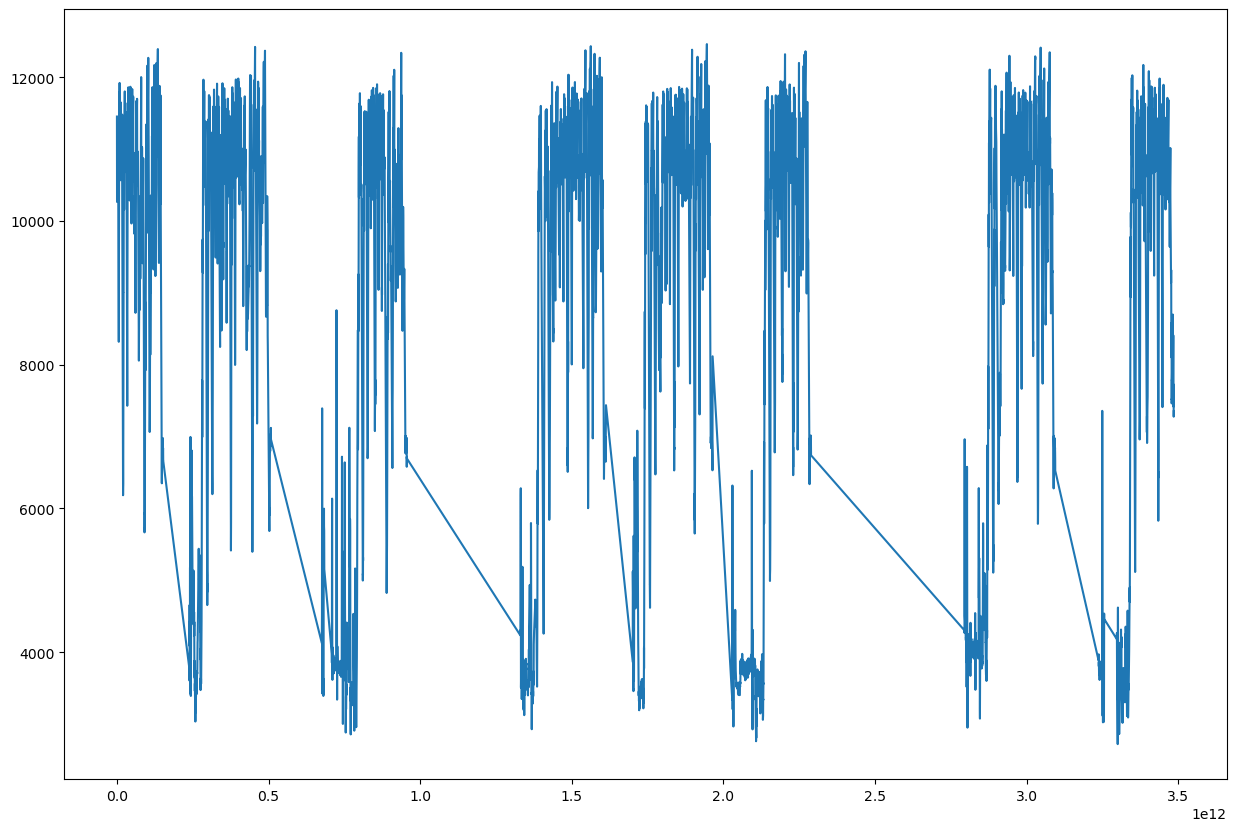

In [78]:
from scipy.signal import savgol_filter

def detect_gear_shifts_with_second_derivative(time, gear, rpm):
    """
    Détecte les moments précis des changements de rapport en utilisant la seconde dérivée du RPM.
    
    :param time: Série temporelle
    :param gear: Série des rapports de vitesse
    :param rpm: Série des RPM du moteur
    :return: Liste des moments précis de changement de rapport et détails
    """
    # Lissage des données RPM avec le filtre Savitzky-Golay
    rpm_smooth = savgol_filter(rpm, window_length=11, polyorder=3)
    
    # Calcul de la première et de la seconde dérivée
    first_derivative = np.gradient(rpm_smooth, time)
    second_derivative = np.gradient(first_derivative, time)
    
    shift_times = []
    shift_details = []
    
    for i in range(1, len(time)):
        if gear[i] != gear[i-1]:
            # Un changement de rapport a été détecté
            # Chercher le point d'inflexion le plus proche dans la seconde dérivée
            start_idx = max(0, i-10)
            end_idx = min(len(time), i+10)
            
            # Trouver le maximum local de la valeur absolue de la seconde dérivée
            local_max_idx = start_idx + np.argmax(np.abs(second_derivative[start_idx:end_idx]))
            
            shift_time = time[local_max_idx]
            shift_times.append(shift_time)
            shift_details.append({
                'time': shift_time,
                'from_gear': gear[i-1],
                'to_gear': gear[i],
                'rpm': rpm_smooth[local_max_idx],
                'second_derivative': second_derivative[local_max_idx]
            })
    
    return shift_times, shift_details

# Exemple d'utilisation
# Supposons que vous ayez un DataFrame 'df' avec les colonnes 'Time', 'nGear', et 'RPM'
shift_times, shift_details = detect_gear_shifts_with_second_derivative(
    df['Time'].values, df['nGear'].values, df['RPM'].values
)

# Afficher les résultats
for detail in shift_details:
    print(f"Changement de rapport à {detail['time']}s: "
          f"de {detail['from_gear']} à {detail['to_gear']}, "
          f"RPM: {detail['rpm']:.0f}, "
          f"Second dérivée: {detail['second_derivative']}")

# Optionnel : créer un DataFrame avec les détails des changements
shifts_df = pd.DataFrame(shift_details)

# Visualisation (optionnelle)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(df['Time'], df['RPM'], label='RPM')
plt.plot(df['Time'], df['rpm'], label='RPM lissé')
plt.plot(shift_times, [df['RPM'].iloc[df['Time'].searchsorted(t)] for t in shift_times], 'ro', label='Changements de rapport')

plt.title('Détection des changements de rapport')
plt.xlabel('Temps')
plt.ylabel('RPM')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from scipy.signal import savgol_filter

def detect_brake_and_throttle_events(time, speed, throttle, brake):
    """
    Détecte les moments précis de freinage et de reprise de l'accélérateur.
    
    :param time: Série temporelle
    :param speed: Série de la vitesse du véhicule
    :param throttle: Série de la position de l'accélérateur (0-100%)
    :param brake: Série de la pression de freinage (0-100%)
    :return: Listes des moments de freinage et d'accélération
    """
    # Lissage des données
    speed_smooth = savgol_filter(speed, window_length=11, polyorder=3)
    throttle_smooth = savgol_filter(throttle, window_length=11, polyorder=3)
    brake_smooth = savgol_filter(brake, window_length=11, polyorder=3)
    
    # Calcul des dérivées
    speed_d2 = np.gradient(np.gradient(speed_smooth, time), time)
    throttle_d2 = np.gradient(np.gradient(throttle_smooth, time), time)
    brake_d2 = np.gradient(np.gradient(brake_smooth, time), time)
    
    brake_events = []
    throttle_events = []
    
    # Seuils pour la détection (à ajuster selon vos données)
    brake_threshold = np.std(brake_d2) * 2
    throttle_threshold = np.std(throttle_d2) * 2
    
    for i in range(1, len(time)):
        # Détection de freinage
        if brake_d2[i] > brake_threshold and brake_smooth[i] > brake_smooth[i-1]:
            brake_events.append({
                'time': time[i],
                'brake_pressure': brake_smooth[i],
                'speed': speed_smooth[i]
            })
        
        # Détection de reprise d'accélération
        if throttle_d2[i] > throttle_threshold and throttle_smooth[i] > throttle_smooth[i-1]:
            throttle_events.append({
                'time': time[i],
                'throttle_position': throttle_smooth[i],
                'speed': speed_smooth[i]
            })
    
    return brake_events, throttle_events

# Exemple d'utilisation
# Supposons que vous ayez un DataFrame 'df' avec les colonnes 'Time', 'Speed', 'Throttle', et 'Brake'
brake_events, throttle_events = detect_brake_and_throttle_events(
    df['Time'].values, df['Speed'].values, df['Throttle'].values, df['Brake'].values
)

# Afficher les résultats
print("Événements de freinage :")
for event in brake_events:
    print(f"Temps: {event['time']:.3f}s, Pression de frein: {event['brake_pressure']:.2f}%, Vitesse: {event['speed']:.1f} km/h")

print("\nÉvénements d'accélération :")
for event in throttle_events:
    print(f"Temps: {event['time']:.3f}s, Position accélérateur: {event['throttle_position']:.2f}%, Vitesse: {event['speed']:.1f} km/h")

# Visualisation (optionnelle)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(df['Time'], df['Speed'], label='Vitesse')
plt.plot(df['Time'], df['Throttle'], label='Accélérateur')
plt.plot(df['Time'], df['Brake'], label='Frein')

brake_times = [event['time'] for event in brake_events]
throttle_times = [event['time'] for event in throttle_events]

plt.scatter(brake_times, [df['Speed'].iloc[df['Time'].searchsorted(t)] for t in brake_times], color='red', label='Freinage')
plt.scatter(throttle_times, [df['Speed'].iloc[df['Time'].searchsorted(t)] for t in throttle_times], color='green', label='Accélération')

plt.title('Détection des événements de freinage et d\'accélération')
plt.xlabel('Temps')
plt.ylabel('Vitesse / Position des pédales')
plt.legend()
plt.grid(True)
plt.show()

Changement de rapport à 1547000000 nanosecondss: de 7 à 8, RPM avant: 11543.72727272728, RPM après: 8451.54778554781, Tombée de RPM: 3092.17948717947
Changement de rapport à 6667000000 nanosecondss: de 8 à 4, RPM avant: 11548.324009324042, RPM après: 9344.310023310049, Tombée de RPM: 2204.0139860139934
Changement de rapport à 6667000000 nanosecondss: de 4 à 5, RPM avant: 11548.324009324042, RPM après: 9344.310023310049, Tombée de RPM: 2204.0139860139934
Changement de rapport à 9386000000 nanosecondss: de 5 à 6, RPM avant: 11502.29603729607, RPM après: 10800.08857808861, Tombée de RPM: 702.2074592074605
Changement de rapport à 9386000000 nanosecondss: de 6 à 7, RPM avant: 11502.29603729607, RPM après: 10800.08857808861, Tombée de RPM: 702.2074592074605
Changement de rapport à 12586000000 nanosecondss: de 7 à 8, RPM avant: 11572.337995338028, RPM après: 10680.664335664365, Tombée de RPM: 891.6736596736628
Changement de rapport à 16747000000 nanosecondss: de 8 à 2, RPM avant: 11882.347319

DTypePromotionError: The DType <class 'numpy.dtypes.TimeDelta64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.TimeDelta64DType'>, <class 'numpy.dtypes.Float64DType'>)

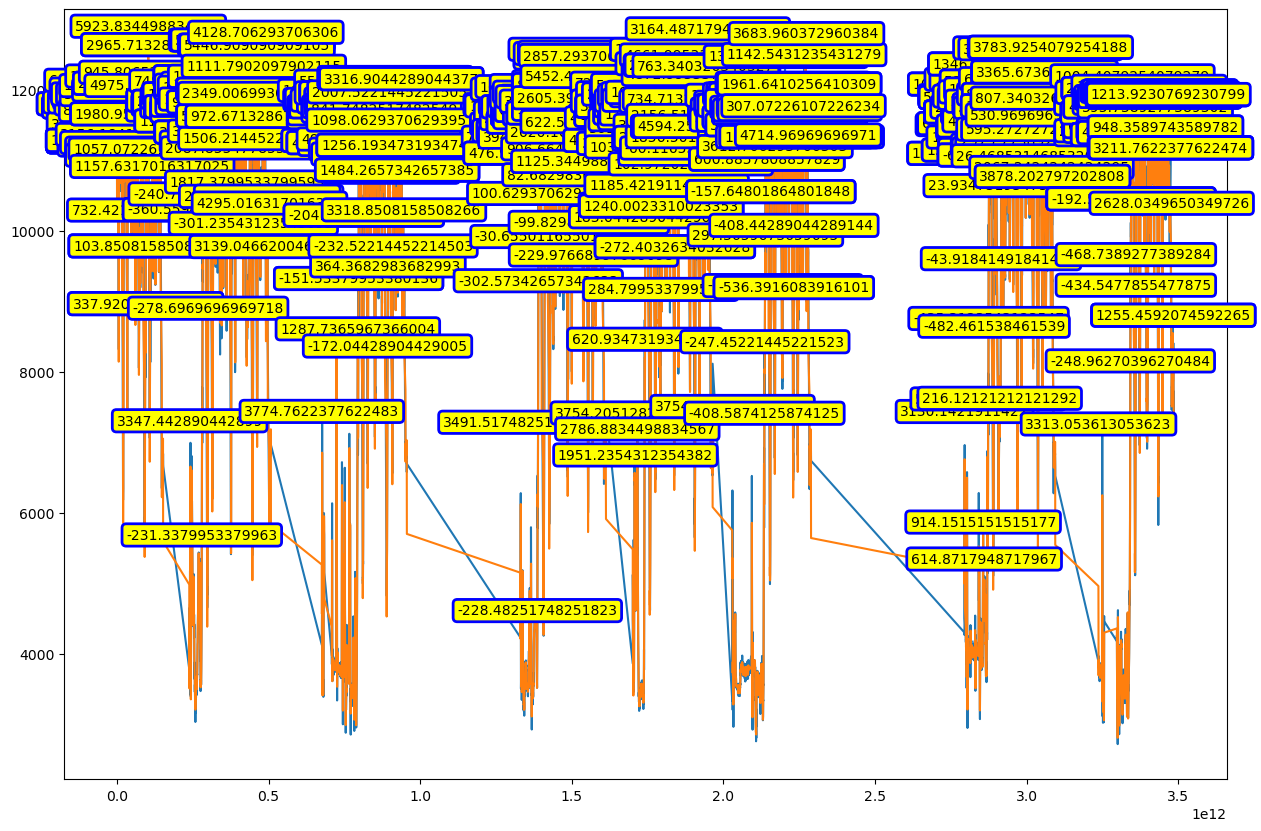

In [81]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

def calculate_rpm_drop(time, gear, rpm):
    """
    Calcule la tombée de RPM entre chaque changement de rapport.
    
    :param time: Série temporelle
    :param gear: Série des rapports de vitesse
    :param rpm: Série des RPM du moteur
    :return: Liste des détails de changement de rapport avec la tombée de RPM
    """
    # Lissage des données RPM
    rpm_smooth = savgol_filter(rpm, window_length=11, polyorder=3)
    
    # Calcul de la première et de la seconde dérivée
    first_derivative = np.gradient(rpm_smooth, time)
    second_derivative = np.gradient(first_derivative, time)
    
    shift_details = []
    
    for i in range(1, len(time)):
        if gear[i] != gear[i-1]:
            # Un changement de rapport a été détecté
            # Chercher le point d'inflexion le plus proche dans la seconde dérivée
            start_idx = max(0, i-10)
            end_idx = min(len(time), i+10)
            
            # Trouver le maximum local de la valeur absolue de la seconde dérivée
            local_max_idx = start_idx + np.argmax(np.abs(second_derivative[start_idx:end_idx]))
            
            # Trouver le RPM maximum avant le changement de rapport
            rpm_before = np.max(rpm_smooth[max(0, local_max_idx-20):local_max_idx])
            
            # Trouver le RPM minimum après le changement de rapport
            rpm_after = np.min(rpm_smooth[local_max_idx:min(len(rpm_smooth), local_max_idx+20)])
            
            # Calculer la tombée de RPM
            rpm_drop = rpm_before - rpm_after
            
            shift_details.append({
                'time': time[local_max_idx],
                'from_gear': gear[i-1],
                'to_gear': gear[i],
                'rpm_before': rpm_before,
                'rpm_after': rpm_after,
                'rpm_drop': rpm_drop
            })
    
    return shift_details,rpm_smooth

# Exemple d'utilisation
# Supposons que vous ayez un DataFrame 'df' avec les colonnes 'Time', 'nGear', et 'RPM'
shift_details,rpm_smooth = calculate_rpm_drop(df['Time'].values, df['nGear'].values, df['RPM'].values)

# Afficher les résultats
for detail in shift_details:
    print(f"Changement de rapport à {detail['time']}s: "
          f"de {detail['from_gear']} à {detail['to_gear']}, "
          f"RPM avant: {detail['rpm_before']}, "
          f"RPM après: {detail['rpm_after']}, "
          f"Tombée de RPM: {detail['rpm_drop']}")

# Optionnel : créer un DataFrame avec les détails des changements
shifts_df = pd.DataFrame(shift_details)

# Visualisation (optionnelle)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(df['Time'], df['RPM'], label='RPM')
plt.plot(df['Time'], rpm_smooth, label='RPM lissé')

for detail in shift_details:
    plt.annotate(f"{detail['rpm_drop']}", 
                 (detail['time'], detail['rpm_before']),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=2))

plt.scatter([d['time'] for d in shift_details], 
            [d['rpm_before'] for d in shift_details], 
            color='red', label='Changements de rapport')

plt.title('Détection des changements de rapport et tombée de RPM')
plt.xlabel('Temps')
plt.ylabel('RPM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

def detect_braking_moments(time, speed, brake):
    """
    Détecte les moments précis de freinage en utilisant la seconde dérivée.
    
    :param time: Série temporelle
    :param speed: Série de la vitesse du véhicule
    :param brake: Série de la pression de freinage (0-100%)
    :return: Liste des moments de freinage détectés
    """
    # Lissage des données
    speed_smooth = savgol_filter(speed, window_length=11, polyorder=3)
    brake_smooth = savgol_filter(brake, window_length=11, polyorder=3)
    
    # Calcul des dérivées
    speed_d1 = np.gradient(speed_smooth, time)
    speed_d2 = np.gradient(speed_d1, time)
    brake_d1 = np.gradient(brake_smooth, time)
    
    braking_moments = []
    
    # Seuils pour la détection (à ajuster selon vos données)
    speed_d2_threshold = np.std(speed_d2) * 2
    brake_threshold = 5  # Supposons qu'une pression de frein > 5% indique un freinage intentionnel
    
    for i in range(1, len(time)):
        # Détection de freinage basée sur la décélération et l'application du frein
        if (speed_d2[i] < -speed_d2_threshold and 
            brake_smooth[i] > brake_threshold and 
            brake_d1[i] > 0):  # S'assurer que la pression de frein augmente
            
            # Trouver le point exact où la décélération est maximale
            start_idx = max(0, i-10)
            end_idx = min(len(time), i+10)
            local_max_decel_idx = start_idx + np.argmin(speed_d2[start_idx:end_idx])
            
            braking_moments.append({
                'time': time[local_max_decel_idx],
                'speed': speed_smooth[local_max_decel_idx],
                'brake_pressure': brake_smooth[local_max_decel_idx],
                'deceleration': speed_d2[local_max_decel_idx]
            })
    
    return braking_moments

# Exemple d'utilisation
# Supposons que vous ayez un DataFrame 'df' avec les colonnes 'Time', 'Speed', et 'Brake'
braking_moments = detect_braking_moments(df['Time'].values, df['Speed'].values, df['Brake'].values)

# Afficher les résultats
for moment in braking_moments:
    print(f"Freinage détecté à {moment['time']:.3f}s, "
          f"Vitesse: {moment['speed']:.1f} km/h, "
          f"Pression de frein: {moment['brake_pressure']:.1f}%, "
          f"Décélération: {moment['deceleration']:.2f} m/s²")

# Visualisation (optionnelle)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(df['Time'], df['Speed'], label='Vitesse')
plt.plot(df['Time'], df['Brake'], label='Frein')

for moment in braking_moments:
    plt.scatter(moment['time'], moment['speed'], color='red', s=100, zorder=5)
    plt.annotate(f"{moment['deceleration']:.2f} m/s²", 
                 (moment['time'], moment['speed']),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=2))

plt.title('Détection des moments de freinage')
plt.xlabel('Temps')
plt.ylabel('Vitesse / Pression de frein')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

def detect_braking_moments(time, speed, brake):
    """
    Détecte les moments précis de freinage en utilisant la seconde dérivée de la vitesse
    et un signal de frein binaire.
    
    :param time: Série temporelle
    :param speed: Série de la vitesse du véhicule
    :param brake: Série du signal de frein (0 ou 1)
    :return: Liste des moments de freinage détectés
    """
    # Lissage des données de vitesse
    speed_smooth = savgol_filter(speed, window_length=11, polyorder=3)
    
    # Calcul des dérivées de la vitesse
    speed_d1 = np.gradient(speed_smooth, time)
    speed_d2 = np.gradient(speed_d1, time)
    
    braking_moments = []
    
    # Seuil pour la détection (à ajuster selon vos données)
    speed_d2_threshold = np.std(speed_d2) * 2
    
    for i in range(1, len(time)):
        # Détection de freinage basée sur la décélération et l'activation du frein
        if (speed_d2[i] < -speed_d2_threshold and 
            brake[i] == 1 and 
            (i == 0 or brake[i-1] == 0)):  # S'assurer que c'est le début du freinage
            
            # Trouver le point exact où la décélération est maximale
            start_idx = max(0, i-10)
            end_idx = min(len(time), i+10)
            local_max_decel_idx = start_idx + np.argmin(speed_d2[start_idx:end_idx])
            
            braking_moments.append({
                'time': time[local_max_decel_idx],
                'speed': speed_smooth[local_max_decel_idx],
                'deceleration': speed_d2[local_max_decel_idx]
            })
    
    return braking_moments

# Exemple d'utilisation
# Supposons que vous ayez un DataFrame 'df' avec les colonnes 'Time', 'Speed', et 'Brake'
braking_moments = detect_braking_moments(df['Time'].values, df['Speed'].values, df['Brake'].values)

# Afficher les résultats
for moment in braking_moments:
    print(f"Freinage détecté à {moment['time']:.3f}s, "
          f"Vitesse: {moment['speed']:.1f} km/h, "
          f"Décélération: {moment['deceleration']:.2f} m/s²")

# Visualisation (optionnelle)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(df['Time'], df['Speed'], label='Vitesse')
plt.plot(df['Time'], df['Brake'] * np.max(df['Speed']), label='Frein (activé/désactivé)', linestyle='--')

for moment in braking_moments:
    plt.scatter(moment['time'], moment['speed'], color='red', s=100, zorder=5)
    plt.annotate(f"{moment['deceleration']:.2f} m/s²", 
                 (moment['time'], moment['speed']),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=2))

plt.title('Détection des moments de freinage')
plt.xlabel('Temps')
plt.ylabel('Vitesse / Signal de frein')
plt.legend()
plt.grid(True)
plt.show()


Changement de rapport à 786000000 nanosecondss: de 7 à 8, RPM: 10650.620046620077, Vitesse: 301.2447552447561 km/h, Tombée de RPM: 39.10722610720222
Changement de rapport à 3546000000 nanosecondss: de 8 à 4, RPM: 10708.37062937066, Vitesse: 282.6340326340335 km/h, Tombée de RPM: -578.2750582750596
Changement de rapport à 8467000000 nanosecondss: de 4 à 5, RPM: 11458.067599067632, Vitesse: 212.55710955711015 km/h, Tombée de RPM: -573.4638694638707
Changement de rapport à 8467000000 nanosecondss: de 5 à 6, RPM: 11458.067599067632, Vitesse: 212.55710955711015 km/h, Tombée de RPM: -73.87645687645636
Changement de rapport à 9828000000 nanosecondss: de 6 à 7, RPM: 11572.337995338028, Vitesse: 251.303030303031 km/h, Tombée de RPM: -642.8391608391648
Changement de rapport à 12146000000 nanosecondss: de 7 à 8, RPM: 11080.379953379985, Vitesse: 294.153846153847 km/h, Tombée de RPM: -164.9114219114217
Changement de rapport à 16747000000 nanosecondss: de 8 à 2, RPM: 10422.20979020982, Vitesse: 272

DTypePromotionError: The DType <class 'numpy.dtypes.TimeDelta64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.TimeDelta64DType'>, <class 'numpy.dtypes.Float64DType'>)

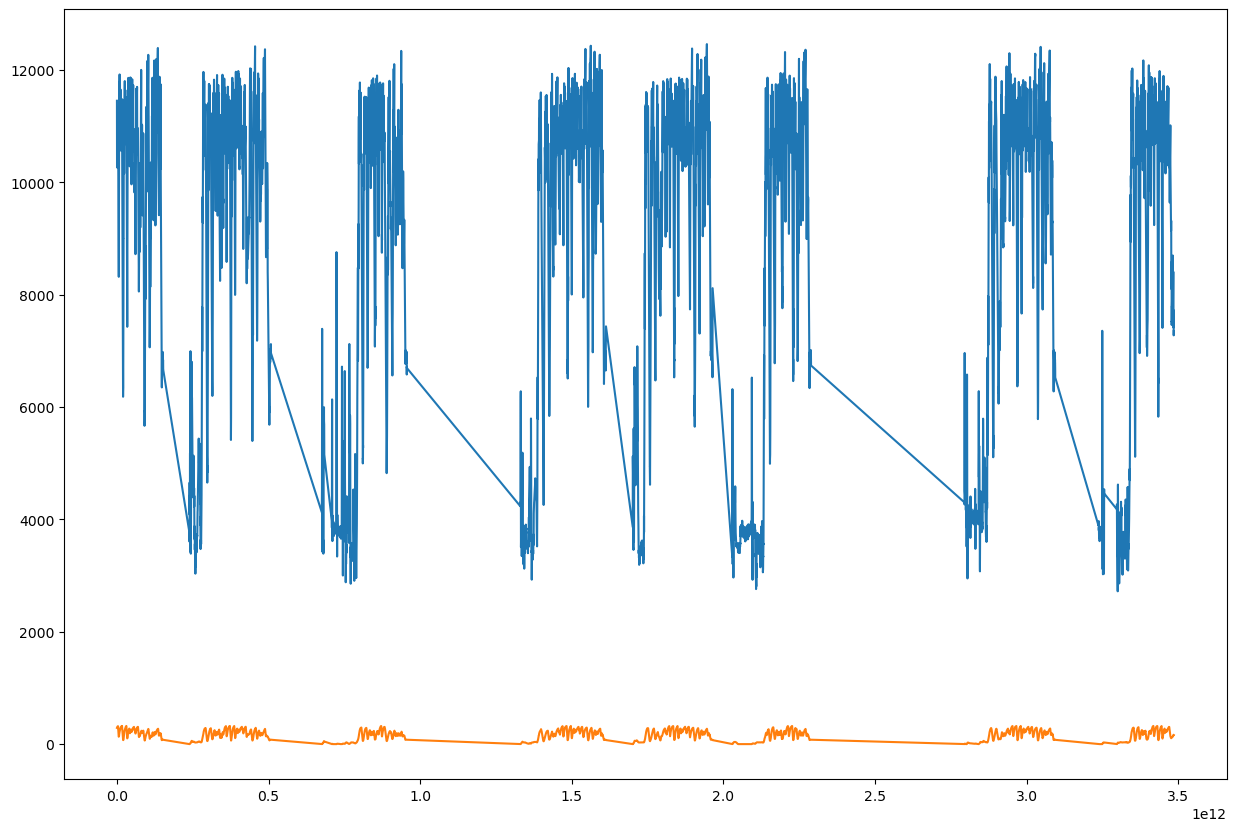

In [83]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

def detect_gear_shifts(time, gear, rpm, speed):
    """
    Détecte les moments précis des changements de rapport en utilisant la seconde dérivée du RPM.
    
    :param time: Série temporelle
    :param gear: Série des rapports de vitesse
    :param rpm: Série des RPM du moteur
    :param speed: Série de la vitesse du véhicule
    :return: Liste des moments de changement de rapport détectés
    """
    # Lissage des données RPM et vitesse
    window_length = 11  # Ajustez en fonction de votre fréquence d'échantillonnage
    rpm_smooth = savgol_filter(rpm, window_length=window_length, polyorder=3)
    speed_smooth = savgol_filter(speed, window_length=window_length, polyorder=3)
    
    # Calcul des dérivées du RPM
    rpm_d1 = np.gradient(rpm_smooth, time)
    rpm_d2 = np.gradient(rpm_d1, time)
    
    gear_shifts = []
    
    for i in range(1, len(time)):
        if gear[i] != gear[i-1]:
            # Un changement de rapport a été détecté
            # Chercher le point d'inflexion le plus proche dans la seconde dérivée du RPM
            start_idx = max(0, i-5)
            end_idx = min(len(time), i+5)
            
            # Trouver le minimum local de la seconde dérivée du RPM
            local_min_idx = start_idx + np.argmin(rpm_d2[start_idx:end_idx])
            
            gear_shifts.append({
                'time': time[local_min_idx],
                'from_gear': gear[i-1],
                'to_gear': gear[i],
                'rpm': rpm_smooth[local_min_idx],
                'speed': speed_smooth[local_min_idx],
                'rpm_drop': rpm_smooth[i-1] - rpm_smooth[local_min_idx]
            })
    
    return gear_shifts

# Exemple d'utilisation
# Supposons que vous ayez un DataFrame 'df' avec les colonnes 'Time', 'nGear', 'RPM', et 'Speed'
gear_shifts = detect_gear_shifts(df['Time'].values, df['nGear'].values, df['RPM'].values, df['Speed'].values)

# Afficher les résultats
for shift in gear_shifts:
    print(f"Changement de rapport à {shift['time']}s: "
          f"de {shift['from_gear']} à {shift['to_gear']}, "
          f"RPM: {shift['rpm']}, "
          f"Vitesse: {shift['speed']} km/h, "
          f"Tombée de RPM: {shift['rpm_drop']}")

# Visualisation (optionnelle)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(df['Time'], df['RPM'], label='RPM')
plt.plot(df['Time'], df['Speed'], label='Vitesse (km/h)')

for shift in gear_shifts:
    plt.scatter(shift['time'], shift['rpm'], color='red', s=100, zorder=5)
    plt.annotate(f"{shift['from_gear']} -> {shift['to_gear']}\n{shift['rpm_drop']:.0f} RPM", 
                 (shift['time'], shift['rpm']),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=2))

plt.title('Détection des changements de rapport')
plt.xlabel('Temps')
plt.ylabel('RPM / Vitesse')
plt.legend()
plt.grid(True)
plt.show()
